# DiD

In [1]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 3, Finished, Available, Finished, False)

In [2]:
%run ./did_model

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 4, Finished, Available, Finished, True)

In [3]:
# Settings
match_method = "calendar2"
outcome_col = "top3_mean_consumption"

EVENT_WINDOW = (-12, 12)
REFERENCE_EVENT_TIME = -1

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 5, Finished, Available, Finished, False)

In [4]:
# Read data
matches = pd.read_parquet(
    f"/lakehouse/default/Files/output/matching_high/{match_method}/matches"
)

month_result = pd.read_parquet(
    "/lakehouse/default/Files/month_data"
)

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 6, Finished, Available, Finished, False)

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 7, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 147


Running cohort 2025-12, treated households = 121


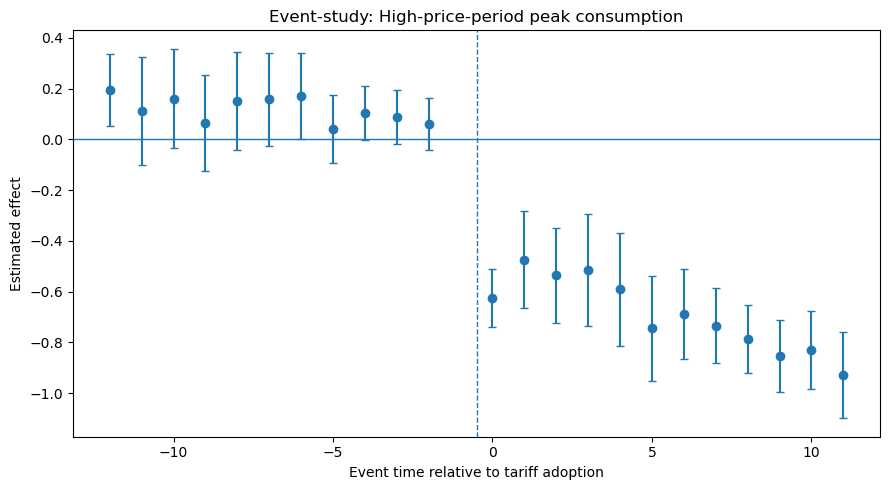

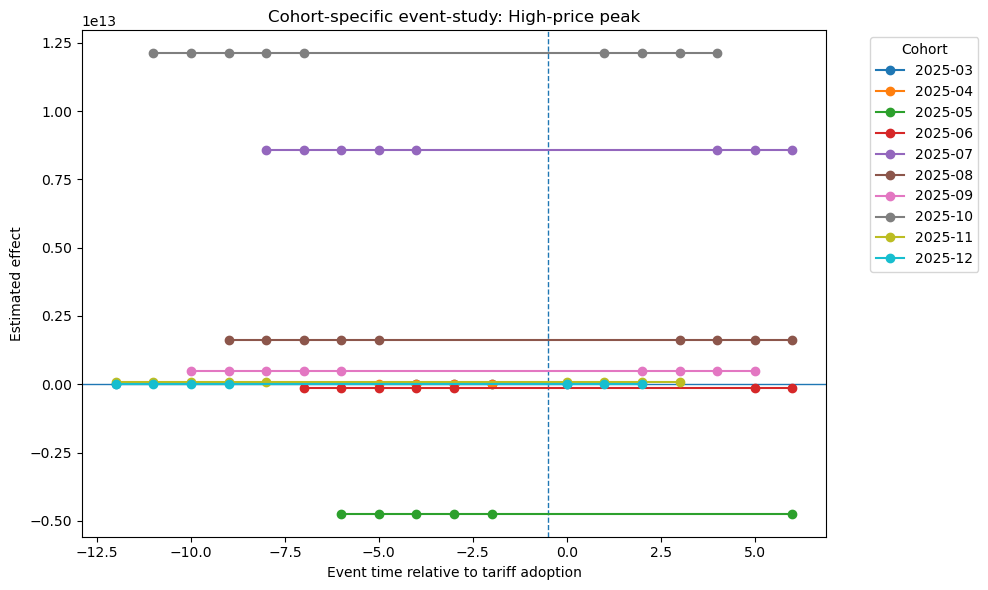

In [5]:
price_value = "high"

df_high = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_high = build_matched_panel(
    matches=matches,
    month_result=df_high,
    outcome_col=outcome_col
)

model_high, result_high = run_basic_did_one(
    matched_high,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models, cohort_basic_results_df = run_basic_did_by_cohort(
    df=matched_high,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_high, event_results_high = run_event_study_one(
    matched_high,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models, cohort_event_results_df = run_event_study_by_cohort(
    df=matched_high,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_high,
    outcome_col=outcome_col,
    title="Event-study: High-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: High-price peak"
)

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 8, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 147


Running cohort 2025-12, treated households = 121


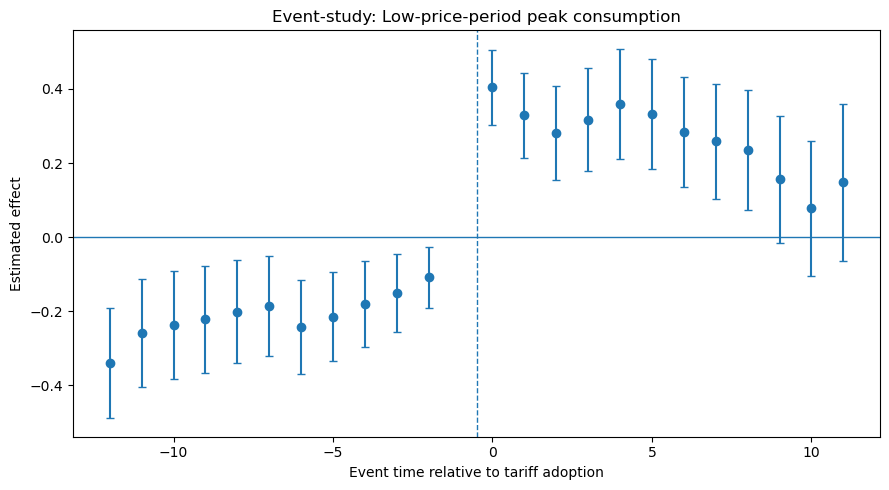

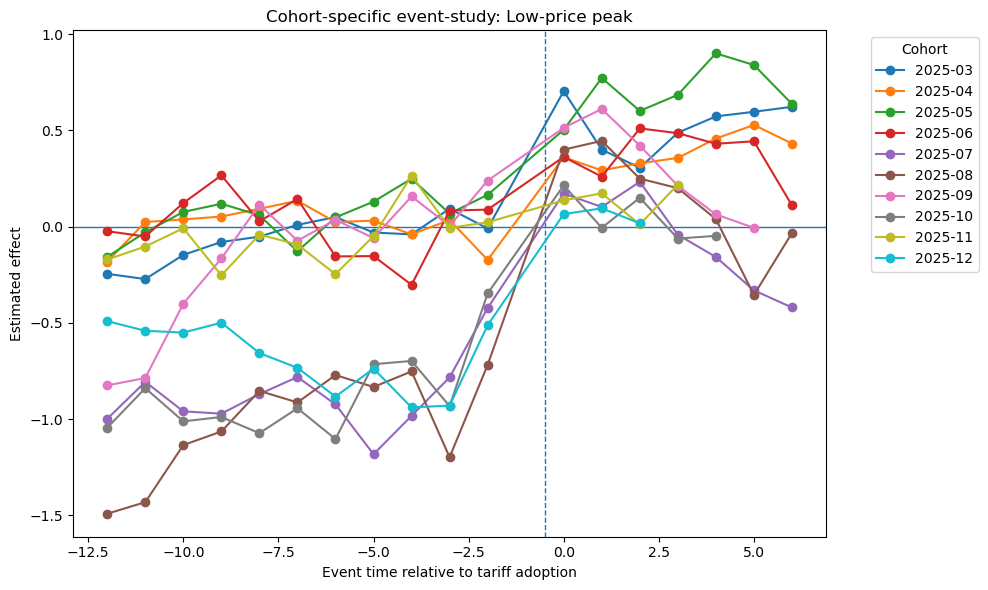

In [6]:
# ============================================================
# LOW PRICE PERIOD
# ============================================================

price_value = "low"

df_low = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_low = build_matched_panel(
    matches=matches,
    month_result=df_low,
    outcome_col=outcome_col
)

model_low, result_low = run_basic_did_one(
    matched_low,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models_low, cohort_basic_results_df_low = run_basic_did_by_cohort(
    df=matched_low,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_low, event_results_low = run_event_study_one(
    matched_low,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models_low, cohort_event_results_df_low = run_event_study_by_cohort(
    df=matched_low,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_low,
    outcome_col=outcome_col,
    title="Event-study: Low-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df_low,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: Low-price peak"
)

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 9, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 147


Running cohort 2025-12, treated households = 121


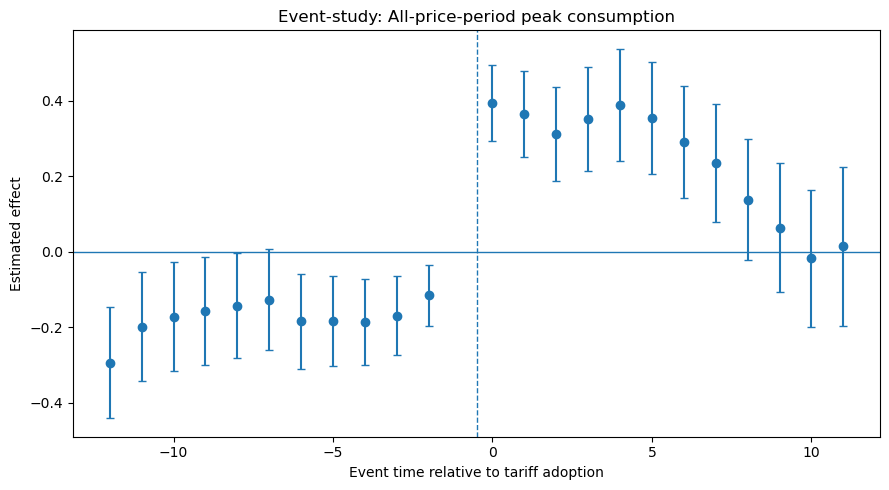

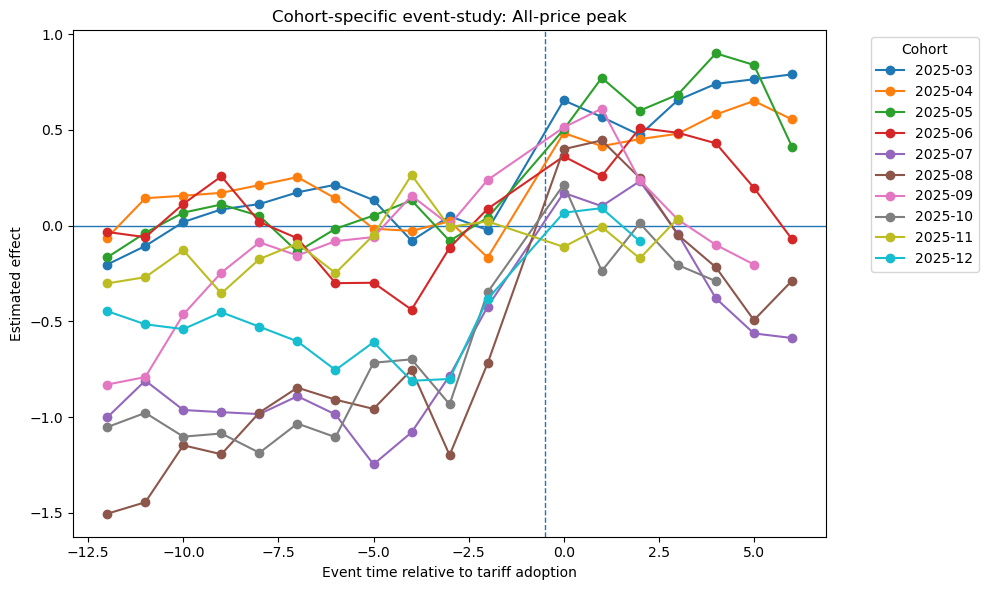

In [7]:
# ============================================================
# ALL PRICE PERIOD
# ============================================================

price_value = "all"

df_all = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_all = build_matched_panel(
    matches=matches,
    month_result=df_all,
    outcome_col=outcome_col
)

model_all, result_all = run_basic_did_one(
    matched_all,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models_all, cohort_basic_results_df_all = run_basic_did_by_cohort(
    df=matched_all,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_all, event_results_all = run_event_study_one(
    matched_all,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models_all, cohort_event_results_df_all = run_event_study_by_cohort(
    df=matched_all,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_all,
    outcome_col=outcome_col,
    title="Event-study: All-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df_all,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: All-price peak"
)

In [11]:
# ============================================================
# HIGH PRICE PERIOD
# ============================================================

print_result_table(
    result_high,
    title="HIGH PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df,
    title="HIGH PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_high,
    title="HIGH PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df,
    title="HIGH PRICE PERIOD — Cohort-specific Event-study"
)



StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 13, Finished, Available, Finished, False)


HIGH PRICE PERIOD — Basic DiD
              outcome    coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption -0.8423     0.0444      0.0   -0.9294   -0.7553 155008        9289

HIGH PRICE PERIOD — Cohort-specific DiD
 cohort               outcome    coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption -0.9586     0.0674   0.0000   -1.0906   -0.8265        625          5  53918        3206
2025-04 top3_mean_consumption -0.7414     0.0864   0.0000   -0.9107   -0.5721        334          4  30967        1847
2025-05 top3_mean_consumption -0.9513     0.1453   0.0000   -1.2361   -0.6665        140          4  13177         793
2025-06 top3_mean_consumption -0.8780     0.1542   0.0000   -1.1802   -0.5758        125          4  12046         725
2025-07 top3_mean_consumption -0.9804     0.2314   0.0000   -1.4338   -0.5269         64          4   6044         368
2025-08 top3_mean_consumption -0.944

In [12]:

# ============================================================
# LOW PRICE PERIOD
# ============================================================

print_result_table(
    result_low,
    title="LOW PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df_low,
    title="LOW PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_low,
    title="LOW PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df_low,
    title="LOW PRICE PERIOD — Cohort-specific Event-study"
)

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 14, Finished, Available, Finished, False)


LOW PRICE PERIOD — Basic DiD
              outcome   coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption 0.6544     0.0588      0.0    0.5392    0.7697 346245        9289

LOW PRICE PERIOD — Cohort-specific DiD
 cohort               outcome   coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption 0.7504     0.0962   0.0000    0.5618    0.9390        625         12 120424        3206
2025-04 top3_mean_consumption 0.5428     0.1198   0.0000    0.3080    0.7775        334         11  69183        1847
2025-05 top3_mean_consumption 0.7881     0.2148   0.0002    0.3671    1.2091        140         10  29446         793
2025-06 top3_mean_consumption 0.4124     0.2105   0.0501   -0.0002    0.8249        125          9  26892         725
2025-07 top3_mean_consumption 0.9813     0.3243   0.0025    0.3456    1.6169         64          8  13495         368
2025-08 top3_mean_consumption 1.4166     0.335

In [13]:


# ============================================================
# ALL PRICE PERIOD
# ============================================================

print_result_table(
    result_all,
    title="ALL PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df_all,
    title="ALL PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_all,
    title="ALL PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df_all,
    title="ALL PRICE PERIOD — Cohort-specific Event-study"
)
     

StatementMeta(, b5e01055-a871-4a77-ab57-bdd374af38f5, 15, Finished, Available, Finished, False)


ALL PRICE PERIOD — Basic DiD
              outcome   coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption 0.6231     0.0586      0.0    0.5083     0.738 346245        9289

ALL PRICE PERIOD — Cohort-specific DiD
 cohort               outcome   coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption 0.7250     0.0958   0.0000    0.5372    0.9128        625         12 120424        3206
2025-04 top3_mean_consumption 0.5260     0.1192   0.0000    0.2924    0.7596        334         11  69183        1847
2025-05 top3_mean_consumption 0.7450     0.2129   0.0005    0.3276    1.1624        140         10  29446         793
2025-06 top3_mean_consumption 0.3978     0.2102   0.0584   -0.0141    0.8097        125          9  26892         725
2025-07 top3_mean_consumption 0.9037     0.3228   0.0051    0.2711    1.5364         64          8  13495         368
2025-08 top3_mean_consumption 1.3176     0.332